In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import pennylane as qml
from pennylane.qnn import TorchLayer

# ─────────────────────────────────────────────────────────────────────
# WHAT CHANGED FROM v2 AND WHY
# ─────────────────────────────────────────────────────────────────────
#
#  PROBLEM: Train=99.9% vs Val=92.7% → 7.2% overfitting gap
#  CAUSE:   716K-param backbone memorizes GAN-balanced training data
#
#  FIX STRATEGY: Shrink & regularise backbone so it CAN'T memorise.
#  Force the quantum layer to do more discriminative work.
#
#  Key changes:
#  1. Backbone channels:   32→64→128  becomes  16→32→64   (-75% params)
#  2. MixUp regularisation on training batches (no domain knowledge needed)
#  3. Quantum: n_qubits=8, q_depth=6, 3-axis measurement (kept from v2)
#  4. Stronger bridge dropout: 0.2 → 0.35
#  5. Backbone dropout: 0.15 → 0.20
#  6. Stochastic depth rates increased: 0.05/0.10/0.15 → 0.10/0.15/0.20
#  7. Label smoothing: 0.1 → 0.15
#  8. Weight decay: 1e-4 → 3e-4
#  9. SAM (Sharpness-Aware Minimisation) optimizer wrapper
#     → finds flatter minima → better generalisation
# ─────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────
# SEEDING
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
n_qubits     = 8
q_depth      = 6
q_out_dim    = 3 * n_qubits    # 24 features from 3-axis Pauli measurement
batch_size   = 32
num_classes  = 10
num_epochs   = 80
lr           = 0.0005
weight_decay = 3e-4             # ↑ from 1e-4 — stronger L2 penalty

# ─────────────────────────────────────────────
# TRANSFORMS
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ─────────────────────────────────────────────
# DATASETS & LOADERS
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train_balanced_v2'
TEST_PATH  = 'virus_MNIST dataset/test'
VAL_PATH   = 'virus_MNIST dataset/val'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=train_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    val_dataset   = ImageFolder(VAL_PATH,   transform=eval_transform)
    print("Datasets loaded successfully")
except Exception as e:
    print(f"Error loading datasets: {e}")

try:
    labels = [label for _, label in train_dataset.samples]
    class_weights = compute_class_weight(
        class_weight='balanced', classes=np.unique(labels), y=labels
    )
    class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print("Class weights computed:", class_weights)
except Exception as e:
    print(f"Could not compute class weights: {e}. Using uniform weights.")
    class_weight_tensor = torch.ones(num_classes).to(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)

# ─────────────────────────────────────────────
# SAM — Sharpness-Aware Minimisation
# ─────────────────────────────────────────────
# SAM finds parameter regions with uniformly low loss (flat minima)
# rather than sharp valleys. Flat minima generalise much better.
# Particularly effective when train acc >> val acc (our exact problem).
# Usage: two forward+backward passes per batch (slightly slower).
# ─────────────────────────────────────────────
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer_cls, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer_cls(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None:
                    continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)                     # move to perturbed weights
                self.state[p]["e_w"] = e_w

        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]["e_w"])    # restore original weights

        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        # Compute global grad norm across all param groups
        norms = [
            p.grad.norm(p=2).to(self.param_groups[0]["params"][0])
            for group in self.param_groups
            for p in group["params"]
            if p.grad is not None
        ]
        return torch.stack(norms).norm(p=2)

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups


# ─────────────────────────────────────────────
# MIXUP  — input-space regularisation
# ─────────────────────────────────────────────
# Mixes pairs of training samples and their labels.
# Forces the model to learn smooth decision boundaries.
# Does NOT require domain knowledge about the data.
# α=0.2 gives subtle mixing; increase to 0.4 for stronger effect.
# ─────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, torch.ones(x.size(0), device=x.device)

    lam    = np.random.beta(alpha, alpha)
    lam    = max(lam, 1 - lam)             # ensure dominant class stays dominant
    index  = torch.randperm(x.size(0), device=x.device)
    x_mix  = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return x_mix, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ─────────────────────────────────────────────
# FOCAL LOSS (kept from v2)
# ─────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.15):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing   # ↑ 0.10→0.15

    def forward(self, inputs, targets):
        ce_loss    = F.cross_entropy(
            inputs, targets,
            weight           = self.weight,
            label_smoothing  = self.label_smoothing,
            reduction        = 'none'
        )
        pt         = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


# ─────────────────────────────────────────────
# QUANTUM CIRCUIT  (kept from v2 — already optimal)
# ─────────────────────────────────────────────
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Initial angle encoding
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)
        qml.RZ(inputs[..., i + n_qubits], wires=i)

    # Variational layers with data re-uploading + brick-layer CRZ
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])

        # Re-upload: data + trainable weights fused per layer
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)

    # 3-axis Pauli measurement → 24 features
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}


# ─────────────────────────────────────────────
# BUILDING BLOCKS
# ─────────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):    # reduction 8→4 for small channel counts
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = self.se(out)
        if self.training and self.drop_path_rate > 0:
            keep_prob     = 1 - self.drop_path_rate
            random_tensor = (
                torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob
            ).float()
            out = out * random_tensor / keep_prob
        return self.relu(out + self.skip(x))


# ─────────────────────────────────────────────
# QUANTUM BRIDGE v3 — stronger dropout
# ─────────────────────────────────────────────
class QuantumBridge(nn.Module):
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),     # 64→32 — proportional to smaller backbone
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(0.35),              # ↑ from 0.20 — critical chokepoint regularisation
            nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        x = self.project(x)
        return self.angle_scale * torch.sigmoid(x) + self.angle_bias


# ─────────────────────────────────────────────
# MAIN MODEL  — HybridResNet v3
# ─────────────────────────────────────────────
#
#  KEY CHANGE: Backbone channels halved
#  Old: stem→32, stage1→32, stage2→64, stage3→128  (~716K params)
#  New: stem→16, stage1→16, stage2→32, stage3→64   (~180K params)
#
#  Smaller backbone → less memorisation capacity → forced to
#  learn generalisable features → quantum layer contribution matters more
#
class HybridResNet(nn.Module):
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()

        # ── Smaller Classical Backbone ────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        # Progressive stochastic depth: shallower=less drop, deeper=more drop
        self.stage1 = nn.Sequential(
            ResBlock(16, 16,  drop_path=0.10),
            ResBlock(16, 16,  drop_path=0.10)
        )
        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),
            ResBlock(32, 32,           drop_path=0.15)
        )
        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),
            ResBlock(64, 64,           drop_path=0.20)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)

        # ── Quantum Bridge ────────────────────────────────────────
        self.bridge = QuantumBridge(in_features=64, n_qubits=n_qubits)

        # ── Quantum Layer ─────────────────────────────────────────
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)

        # ── Classifier Head ───────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),   # 24→48
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(q_out_dim * 2, num_classes)   # 48→10
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)    # (B, 64)
        x = self.bridge(x)            # (B, 2*n_qubits = 16)
        x = self.q_layer(x)           # (B, 3*n_qubits = 24)
        return self.classifier(x)


# ─────────────────────────────────────────────
# TRAINING & EVALUATION
# ─────────────────────────────────────────────
def train_epoch(model, dataloader, loss_fn, optimizer, scheduler, device,
                mixup_alpha=0.2, use_sam=True):
    model.train()
    total_loss, correct = 0.0, 0

    for inputs, labels in tqdm(dataloader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        # MixUp augmentation in feature space — no domain knowledge needed
        inputs_mix, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=mixup_alpha)

        if use_sam:
            # ── SAM first pass: compute loss at perturbed weights ──
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()
            optimizer.first_step(zero_grad=True)

            # ── SAM second pass: compute loss at restored weights ──
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.second_step(zero_grad=True)
        else:
            optimizer.zero_grad()
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        # For accuracy tracking use non-mixed labels (dominant class)
        correct += (outputs.argmax(dim=1) == labels).sum().item()

    return total_loss / len(dataloader), correct / len(dataloader.dataset)


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = model(inputs)
            loss           = loss_fn(outputs, labels)
            total_loss    += loss.item()
            _, predicted   = torch.max(outputs, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    return total_loss / len(dataloader), correct / total


# ─────────────────────────────────────────────
# MODEL, OPTIMIZER, LOSS, SCHEDULER
# ─────────────────────────────────────────────
model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# Base AdamW optimizer (wrapped by SAM)
base_optimizer = torch.optim.AdamW

# SAM wraps AdamW with sharpness-aware perturbation
optimizer = SAM(
    [
        {'params': model.stem.parameters(),       'lr': lr},
        {'params': model.stage1.parameters(),     'lr': lr},
        {'params': model.stage2.parameters(),     'lr': lr},
        {'params': model.stage3.parameters(),     'lr': lr},
        {'params': model.bridge.parameters(),     'lr': lr},
        {'params': model.q_layer.parameters(),    'lr': lr * 0.1},
        {'params': model.classifier.parameters(), 'lr': lr},
    ],
    base_optimizer_cls = base_optimizer,
    rho                = 0.05,
    weight_decay       = weight_decay
)

loss_fn = FocalLoss(weight=class_weight_tensor, gamma=2.0, label_smoothing=0.15)

# OneCycleLR — steps per batch inside train_epoch
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer.base_optimizer,
    max_lr             = [lr, lr, lr, lr, lr, lr * 0.1, lr],
    steps_per_epoch    = len(train_loader),
    epochs             = num_epochs,
    pct_start          = 0.3,
    anneal_strategy    = 'cos',
    div_factor         = 10.0,
    final_div_factor   = 1e4
)

# ─────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────
best_val_acc               = 0.0
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []
early_stopping_patience    = 15
epochs_without_improvement = 0

print(f"\nStarting Hybrid v3 Training for {num_epochs} epochs...")
print(f"Backbone: 16→32→64 channels (~180K params) | "
      f"Quantum: {n_qubits} qubits × {q_depth} layers → {q_out_dim} features")
print(f"Regularisation: SAM + MixUp + FocalLoss + StochDepth + Dropout(0.35)")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(
        model, train_loader, loss_fn, optimizer, scheduler, device,
        mixup_alpha=0.2, use_sam=True
    )
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    gap        = train_acc - val_acc
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | LR: {current_lr:.6f} | Gap: {gap:.4f}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc               = val_acc
        epochs_without_improvement = 0
        torch.save({
            'epoch':                epoch + 1,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.base_optimizer.state_dict(),
            'val_acc':              val_acc,
            'val_loss':             val_loss,
            'train_val_gap':        gap,
            'config': {
                'n_qubits':    n_qubits,
                'q_depth':     q_depth,
                'q_out_dim':   q_out_dim,
                'num_classes': num_classes,
                'backbone':    '16→32→64',
            }
        }, "hybrid_resnet_NOGAN.pth")
        print(f"  💾 Best model saved (Val Acc: {best_val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  🕒 No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⏹️  Early stopping triggered after {epoch+1} epochs.")
        break

    print("-" * 70)

print(f"\n✅ Training complete.")
print(f"   Best Val Acc : {best_val_acc:.4f}")
print(f"   Train/Val Gap: {train_accs[val_accs.index(best_val_acc)]:.4f} / {best_val_acc:.4f}")

Using device: cuda
Datasets loaded successfully
Class weights computed: [1.64455748 0.74958269 1.35924888 1.72713675 5.20923738 0.86820623
 0.37487826 0.76944312 1.60483124 1.23593272]
Total trainable parameters: 184,234

Starting Hybrid v3 Training for 80 epochs...
Backbone: 16→32→64 channels (~180K params) | Quantum: 8 qubits × 6 layers → 24 features
Regularisation: SAM + MixUp + FocalLoss + StochDepth + Dropout(0.35)


Epoch [01/80] | LR: 0.000052 | Gap: -0.1432
  Train Loss: 2.1176 | Train Acc: 0.1326
  Val   Loss: 1.5708 | Val   Acc: 0.2758
  💾 Best model saved (Val Acc: 0.2758)
----------------------------------------------------------------------


Epoch [02/80] | LR: 0.000058 | Gap: -0.1247
  Train Loss: 1.9134 | Train Acc: 0.1901
  Val   Loss: 1.4493 | Val   Acc: 0.3149
  💾 Best model saved (Val Acc: 0.3149)
----------------------------------------------------------------------


Epoch [03/80] | LR: 0.000067 | Gap: -0.1126
  Train Loss: 1.8054 | Train Acc: 0.2488
  Val   Loss: 1.3098 | Val   Acc: 0.3614
  💾 Best model saved (Val Acc: 0.3614)
----------------------------------------------------------------------


Epoch [04/80] | LR: 0.000080 | Gap: -0.1276
  Train Loss: 1.6950 | Train Acc: 0.3250
  Val   Loss: 1.1775 | Val   Acc: 0.4526
  💾 Best model saved (Val Acc: 0.4526)
----------------------------------------------------------------------


...

Epoch [56/80] | LR: 0.000194 | Gap: -0.0487
  Train Loss: 0.8533 | Train Acc: 0.8640
  Val   Loss: 0.5285 | Val   Acc: 0.9128
  🕒 No improvement for 1 epoch(s).
----------------------------------------------------------------------


Epoch [57/80] | LR: 0.000181 | Gap: -0.0491
  Train Loss: 0.8453 | Train Acc: 0.8674
  Val   Loss: 0.5227 | Val   Acc: 0.9165
  🕒 No improvement for 2 epoch(s).
----------------------------------------------------------------------


Epoch [58/80] | LR: 0.000167 | Gap: -0.0463
  Train Loss: 0.8320 | Train Acc: 0.8710
  Val   Loss: 0.5274 | Val   Acc: 0.9173
  🕒 No improvement for 3 epoch(s).
----------------------------------------------------------------------


Epoch [59/80] | LR: 0.000154 | Gap: -0.0510
  Train Loss: 0.8478 | Train Acc: 0.8648
  Val   Loss: 0.5317 | Val   Acc: 0.9159
  🕒 No improvement for 4 epoch(s).
----------------------------------------------------------------------


Training:   3%|▎         | 42/1516 [00:14<07:59,  3.08it/s]

In [ ]:
# ─────────────────────────────────────────────
# RESUME TRAINING FROM CHECKPOINT
# ─────────────────────────────────────────────

checkpoint_path = "hybrid_resnet_NOGAN.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

# 1️⃣ Load model weights
model.load_state_dict(checkpoint['model_state_dict'])

# 2️⃣ Load optimizer (base optimizer state only — SAM wrapper handles structure)
optimizer.base_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# 3️⃣ Recover starting epoch
start_epoch = checkpoint['epoch']

best_val_acc = checkpoint['val_acc']

print(f"\n🔁 Resuming training from epoch {start_epoch}")
print(f"   Previous best Val Acc: {best_val_acc:.4f}")
print("=" * 70)

remaining_epochs = num_epochs - start_epoch

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer.base_optimizer,
    max_lr=[lr, lr, lr, lr, lr, lr * 0.1, lr],
    steps_per_epoch=len(train_loader),
    epochs=remaining_epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1e4
)

for epoch in range(start_epoch, num_epochs):

    train_loss, train_acc = train_epoch(
        model, train_loader, loss_fn, optimizer, scheduler, device,
        mixup_alpha=0.2, use_sam=True
    )

    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

    gap        = train_acc - val_acc
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | LR: {current_lr:.6f} | Gap: {gap:.4f}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.base_optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),   # ADD THIS
        'val_acc': val_acc,
        'val_loss': val_loss
    }, checkpoint_path)

        print(f"  💾 Best model updated (Val Acc: {best_val_acc:.4f})")

    print("-" * 70)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

# 1. DEFINE BUILDING BLOCKS (Ensuring parameters like drop_path exist)
# ─────────────────────────────────────────────────────────────────────

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * scale

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = self.se(out)
        if self.training and self.drop_path_rate > 0:
            keep_prob = 1 - self.drop_path_rate
            random_tensor = (torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob).float()
            out = out * random_tensor / keep_prob
        return self.relu(out + self.skip(x))

class QuantumBridge(nn.Module):
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        x = self.project(x)
        return self.angle_scale * torch.sigmoid(x) + self.angle_bias

# 2. DEFINE MAIN MODEL
# ─────────────────────────────────────────────────────────────────────

class HybridResNet(nn.Module):
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(
            ResBlock(16, 16, drop_path=0.10),
            ResBlock(16, 16, drop_path=0.10)
        )
        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),
            ResBlock(32, 32, drop_path=0.15)
        )
        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),
            ResBlock(64, 64, drop_path=0.20)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.bridge = QuantumBridge(64, n_qubits)
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(q_out_dim * 2, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x).view(x.size(0), -1)
        x = self.bridge(x)
        q_features = self.q_layer(x)
        logits = self.classifier(q_features)
        return q_features, logits

# 3. INITIALIZE AND TEST
# ─────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_model = HybridResNet(n_qubits, q_out_dim, num_classes).to(device)

checkpoint = torch.load("hybrid_resnet_NOGAN.pth", map_location=device)
test_model.load_state_dict(checkpoint['model_state_dict'])
test_model.eval()

all_preds, all_labels, all_features = [], [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        features, logits = test_model(inputs)
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_features.extend(features.cpu().numpy())

# 4. RESULTS & t-SNE
# ─────────────────────────────────────────────────────────────────────

acc = accuracy_score(all_labels, all_preds)
print(f"\n🚀 Test Accuracy: {acc:.4f}")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

print("Generating t-SNE Plot...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings = tsne.fit_transform(np.array(all_features))

plt.figure(figsize=(10, 7))
sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], 
                hue=[test_dataset.classes[i] for i in all_labels], 
                palette='viridis', s=20, alpha=0.8)
plt.title(f"Quantum Feature t-SNE (Test Acc: {acc:.2f})")
plt.show()

Using device: cuda
Test samples : 3458
Train samples: 48498 (used only for centroid computation)
Classes (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Loading checkpoint: hybrid_resnet_NOGAN.pth
  Checkpoint from epoch : 55
  Saved val accuracy    : 0.9177
  Training type         : QNI-CCP_only
  Total parameters      : 184,234

STEP 1/4 — FEATURE EXTRACTION



  Samples extracted : 3458
  Feature dimension : 64  (GAP output before bridge)

STEP 2/4 — CLASSIFICATION REPORT

  Clean Test Accuracy : 0.9112  (91.12%)

              precision    recall  f1-score   support

           0     0.5000    0.4171    0.4548       175
           1     0.9980    0.9960    0.9970       496
           2     0.8500    0.9951    0.9169       205
           3     0.9497    0.9659    0.9577       176
           4     1.0000    1.0000    1.0000        58
           5     0.9265    0.9123    0.9193       456
           6     0.9649    0.9332    0.9488      1003
           7     0.8987    0.8676    0.8829       491
           8     0.8602    0.9249    0.8914       173
           9     0.8199    0.9511    0.8807       225

    accuracy                         0.9112      3458
   macro avg     0.8768    0.8963    0.8849      3458
weighted avg     0.9100    0.9112    0.9096      3458


STEP 3/4 — QNI-CCP ROBUSTNESS EVALUATION

Computing training-set centroids for QNI


Applying QNI-CCP attack on test set...



  Clean Test Accuracy         : 0.9112  (91.12%)
  Under QNI-CCP Perturbation  : 0.9057  (90.57%)
  Robustness drop             : 0.55 pp

STEP 4/4 — LATENT-SPACE METRICS (Table 6 style)

  Metric                                   Value
  ---------------------------------------------
  Entropy (avg prediction entropy)        1.3010
  Feature Variance (avg across dims)      0.0719
  Unique Patterns                           2585
  High-confidence patterns (≥90%)           1.9%
  Average confidence                      0.6380
  Confidence std dev                      0.1619

GENERATING PLOTS

Running t-SNE dimensionality reduction...
  Input shape  : (3458, 64)  (N samples × 64 features)
  Output shape : (3458, 2)  (N samples × 2 t-SNE dimensions)


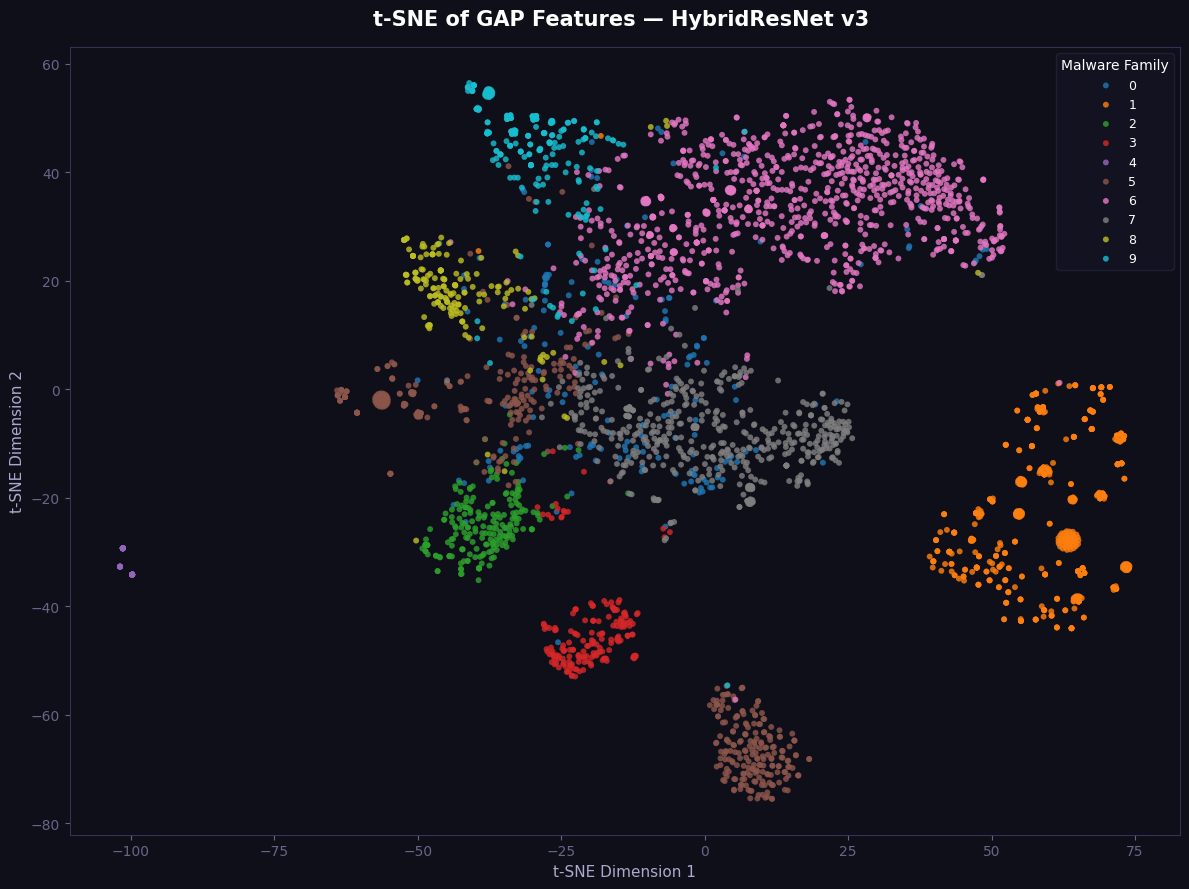

  t-SNE plot saved → tsne_clean_model.png


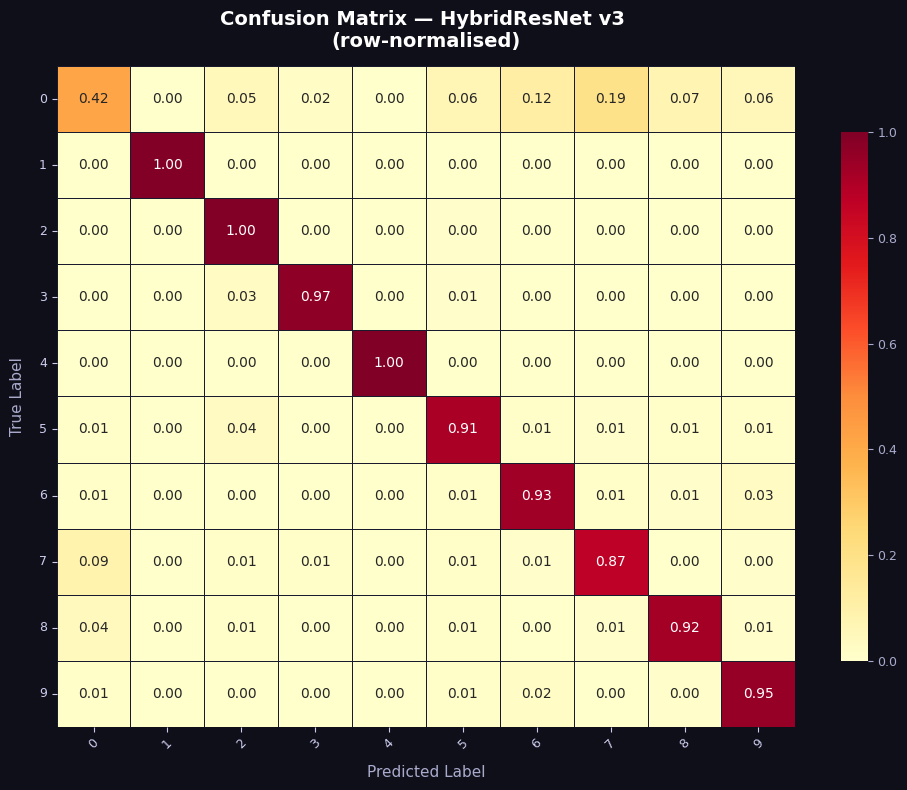

  Confusion matrix saved → confusion_matrix_clean_model.png


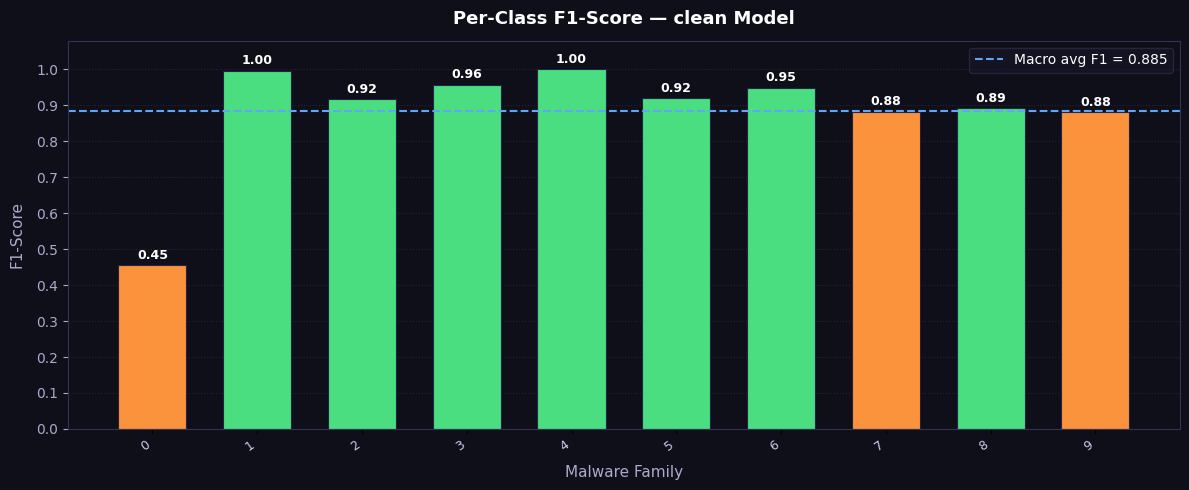

  Per-class F1 bar chart saved → per_class_f1_clean_model.png

EVALUATION SUMMARY

  Model           : HybridResNet v3 — QNI-CCP trained
  Checkpoint      : hybrid_resnet_NOGAN.pth  (epoch 55)
  Test samples    : 3458
  Classes         : 10

  ── Accuracy ──────────────────────────────────────
  Clean accuracy         : 0.9112 (91.12%)
  QNI-CCP robustness     : 0.9057 (90.57%)
  Robustness drop        : 0.55 pp

  ── Classification ────────────────────────────────
  Macro F1               : 0.8849
  Weighted F1            : 0.9096
  Macro Precision        : 0.8768
  Macro Recall           : 0.8963

  ── Latent-Space ──────────────────────────────────
  Entropy (avg)          : 1.3010
  Feature Variance       : 0.0719
  Avg Confidence         : 0.6380
  High-conf patterns     : 1.9%

  ── Saved Plots ───────────────────────────────────
  t-SNE             → tsne_qni_model.png
  Confusion matrix  → confusion_matrix_qni_model.png
  Per-class F1      → per_class_f1_qni_model.png



In [4]:
# in depth evaluation

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.manifold import TSNE                        # dimensionality reduction for t-SNE plot
from sklearn.metrics import (
    classification_report,                               # per-class precision/recall/f1
    confusion_matrix,                                    # class-wise prediction errors
    accuracy_score                                       # overall accuracy
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches                    # for custom legend entries
import seaborn as sns                                    # for confusion matrix heatmap
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION SCRIPT — HybridResNet v3 QNI-CCP Model
#
# WHAT THIS SCRIPT PRODUCES:
#   1. Classification Report  — per-class precision, recall, F1, support
#   2. t-SNE Plot (2D)        — visualise how the 64-dim GAP features cluster
#                               by malware family in 2D space
#   3. Confusion Matrix       — heatmap showing where the model confuses classes
#   4. Summary metrics table  — clean accuracy + QNI-CCP robustness accuracy
#
# HOW t-SNE WORKS HERE:
#   We extract the 64-dim GAP feature vector (z) for every test image.
#   t-SNE reduces these 64 dims → 2 dims while preserving neighbourhood
#   structure: samples with similar features end up close together in 2D.
#   Well-separated, compact clusters → the model has learned discriminative
#   features per malware family. This is Figure 4 from the paper.
#
# HOW TO READ THE CLASSIFICATION REPORT:
#   precision = TP / (TP + FP)  — when model predicts class X, how often correct?
#   recall    = TP / (TP + FN)  — of all actual class X samples, how many found?
#   f1-score  = harmonic mean of precision and recall
#   support   = number of test samples for that class
#   macro avg = unweighted mean across classes (treats all classes equally)
#   weighted  = mean weighted by support (accounts for class imbalance)
# ══════════════════════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────
# SEEDING
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# CONFIG — must match training exactly
# ─────────────────────────────────────────────
n_qubits    = 8
q_depth     = 6
q_out_dim   = 3 * n_qubits    # 24
num_classes = 10
batch_size  = 32              # can increase for faster eval (no gradient needed)

CHECKPOINT_PATH =  "hybrid_resnet_NOGAN.pth"   # your saved QNI-CCP model
EPSILON_Q       = 1.0                                 # same as training


# ─────────────────────────────────────────────
# TRANSFORMS — identical to training eval_transform
# ─────────────────────────────────────────────
eval_transform = transforms.Compose([
    transforms.Grayscale(1),             # single-channel grayscale
    transforms.Resize((32, 32)),         # resize to model input size
    transforms.ToTensor(),               # convert to float tensor [0,1]
    transforms.Normalize((0.5,), (0.5,)) # normalise to [-1, 1]
])


# ─────────────────────────────────────────────
# DATASETS — test set only for evaluation
# Also loading train set for centroid computation
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train_balanced_v2'
TEST_PATH  = 'virus_MNIST dataset/test'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=eval_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    print(f"Test samples : {len(test_dataset)}")
    print(f"Train samples: {len(train_dataset)} (used only for centroid computation)")

    # class_names: list of folder names = malware family names
    # e.g. ['Adware', 'Backdoor', 'Ransomware', ...]
    class_names = test_dataset.classes
    print(f"Classes ({num_classes}): {class_names}")
except Exception as e:
    print(f"Dataset load error: {e}")
    raise

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)


# ══════════════════════════════════════════════════════════════════════════════
# MODEL DEFINITION — byte-for-byte identical to training script
# Must match exactly or load_state_dict() will fail with key mismatches
# ══════════════════════════════════════════════════════════════════════════════

dev_qml = qml.device("default.qubit", wires=n_qubits)   # PennyLane device

@qml.qnode(dev_qml, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Angle encoding: 16 bridge values → RY/RZ rotations on 8 qubits
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)   # first 8 → RY
        qml.RZ(inputs[..., i + n_qubits], wires=i)   # next  8 → RZ
    # Alternating brick entanglement + re-uploading per layer
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)
    # 3-axis Pauli measurements → 24 expectation values ∈ [-1,1]
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}


class SEBlock(nn.Module):
    """Channel attention: (B,C,H,W) → GAP → FC → Sigmoid → channel rescale"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        return x * self.fc(s).view(b, c, 1, 1)


class ResBlock(nn.Module):
    """Residual block with SE attention + stochastic depth"""
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.se(self.conv_block(x))
        if self.training and self.drop_path_rate > 0:
            keep = 1 - self.drop_path_rate
            mask = (torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep).float()
            out  = out * mask / keep
        return self.relu(out + self.skip(x))


class QuantumBridge(nn.Module):
    """Compress 64-dim backbone features → 16 quantum angles: (B,64)→(B,16)"""
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32), nn.LayerNorm(32),
            nn.GELU(), nn.Dropout(0.35), nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        return self.angle_scale * torch.sigmoid(self.project(x)) + self.angle_bias


class HybridResNet(nn.Module):
    """
    HybridResNet v3: (B,1,32,32) → backbone → GAP(B,64) → bridge → q_layer → classifier(B,10)
    GAP output (B,64) is the feature space visualised by t-SNE.
    """
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(ResBlock(16,16,drop_path=0.10), ResBlock(16,16,drop_path=0.10))
        self.stage2 = nn.Sequential(ResBlock(16,32,stride=2,drop_path=0.15), ResBlock(32,32,drop_path=0.15))
        self.stage3 = nn.Sequential(ResBlock(32,64,stride=2,drop_path=0.20), ResBlock(64,64,drop_path=0.20))
        self.gap        = nn.AdaptiveAvgPool2d(1)   # ← t-SNE features extracted here
        self.bridge     = QuantumBridge(64, n_qubits)
        self.q_layer    = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim*2), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(q_out_dim*2, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x); x = self.stage1(x)
        x = self.stage2(x); x = self.stage3(x)
        x = self.gap(x)                   # (B,64,1,1)
        x = x.view(x.size(0), -1)         # (B,64) ← latent space
        x = self.bridge(x)                # (B,16)
        x = self.q_layer(x)               # (B,24)
        return self.classifier(x)         # (B,10)


# ══════════════════════════════════════════════════════════════════════════════
# FEATURE EXTRACTION UTILITIES
# ══════════════════════════════════════════════════════════════════════════════

class FeatureHook:
    """
    Attaches to model.gap and captures (B,64,1,1) output automatically
    on every forward call. Call remove() when done to free memory.
    """
    def __init__(self, layer):
        self.features = None
        self._handle  = layer.register_forward_hook(self._capture)
    def _capture(self, module, inp, output):
        self.features = output
    def remove(self):
        self._handle.remove()


def extract_features_and_predictions(model, dataloader, device):
    """
    Single pass over the dataloader.
    Returns:
      all_features  : (N, 64) numpy array — GAP latent vectors for t-SNE
      all_labels    : (N,)    numpy array — true class indices
      all_preds     : (N,)    numpy array — predicted class indices
      all_probs     : (N, C)  numpy array — softmax probabilities (for confidence)

    Why one pass collects everything:
      The FeatureHook fires during model(x), giving us z (B,64).
      Simultaneously, model(x) returns logits → argmax → predictions.
      This avoids running the forward pass twice.
    """
    model.eval()
    all_features, all_labels, all_preds, all_probs = [], [], [], []

    hook = FeatureHook(model.gap)    # register hook on GAP layer once

    with torch.no_grad():            # no gradient needed for evaluation
        for x, y in tqdm(dataloader, desc="Extracting features", leave=False):
            x, y    = x.to(device), y.to(device)
            logits  = model(x)       # (B,10) — hook also fires, capturing (B,64,1,1)

            # gather GAP features from hook
            z = hook.features.view(hook.features.size(0), -1)   # (B,64,1,1) → (B,64)
            all_features.append(z.cpu().numpy())

            probs = F.softmax(logits, dim=1)                     # (B,10) probabilities
            preds = logits.argmax(dim=1)                         # (B,) predicted class

            all_labels.append(y.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    hook.remove()    # deregister hook to prevent memory leak

    return (
        np.concatenate(all_features, axis=0),   # (N, 64)
        np.concatenate(all_labels,   axis=0),   # (N,)
        np.concatenate(all_preds,    axis=0),   # (N,)
        np.concatenate(all_probs,    axis=0)    # (N, C)
    )


def compute_class_centroids(model, dataloader, device, num_classes):
    """
    Computes mean GAP feature (centroid) per class over the training set.
    Used for QNI robustness evaluation.
    Returns: (num_classes, 64) tensor
    """
    model.eval()
    hook         = FeatureHook(model.gap)
    sum_features = torch.zeros(num_classes, 64, device=device)
    count        = torch.zeros(num_classes,     device=device)

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Computing centroids", leave=False):
            x, y = x.to(device), y.to(device)
            _    = model(x)          # fires hook
            z    = hook.features.view(hook.features.size(0), -1)   # (B,64)
            for c in range(num_classes):
                mask = (y == c)
                if mask.sum() > 0:
                    sum_features[c] += z[mask].sum(dim=0)
                    count[c]        += mask.sum()

    hook.remove()
    return sum_features / count.clamp(min=1.0).unsqueeze(1)   # (num_classes, 64)


def evaluate_qni_robustness(model, dataloader, device, centroids, epsilon_q=1.0):
    """
    Measures accuracy when GAP features are perturbed by QNI-CCP attack.
    This is the adversarial robustness metric — how much does accuracy drop?

    Data flow:
      x → full forward (get z) → compute sensitivity → perturb z toward
      wrong centroid → bridge→q_layer→classifier → accuracy
    Returns: robustness accuracy (float)
    """
    model.eval()
    correct, total = 0, 0

    for x, y in tqdm(dataloader, desc="QNI Robustness Eval", leave=False):
        x, y = x.to(device), y.to(device)

        # Extract z with gradient for sensitivity computation
        hook  = FeatureHook(model.gap)
        _     = model(x)
        z_raw = hook.features.view(hook.features.size(0), -1)
        hook.remove()

        z = z_raw.detach().requires_grad_(True)   # enable grad on z only
        logits = model.classifier(model.q_layer(model.bridge(z)))
        F.cross_entropy(logits, y).backward()     # fills z.grad with sensitivity

        S_norm = z.grad.detach()
        S_norm = S_norm / (S_norm.norm(dim=1, keepdim=True) + 1e-8)   # L2-normalise

        z_det = z.detach()
        wrong = [np.random.choice([c for c in range(centroids.size(0)) if c != yi.item()])
                 for yi in y]
        mu_wrong    = centroids[torch.tensor(wrong, device=device)]   # (B,64)
        z_perturbed = z_det + epsilon_q * (S_norm * (mu_wrong - z_det))

        with torch.no_grad():
            logits_p = model.classifier(model.q_layer(model.bridge(z_perturbed)))
            correct += (logits_p.argmax(1) == y).sum().item()
            total   += y.size(0)

    return correct / total


# ══════════════════════════════════════════════════════════════════════════════
# PLOTTING FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def plot_tsne(features, labels, class_names, title="t-SNE of GAP Features clean model",
              save_path="tsne_qni_model.png"):
    """
    Runs t-SNE on (N, 64) GAP features and plots 2D scatter.

    t-SNE parameters:
      n_components=2    : reduce to 2D for plotting
      perplexity=40     : roughly the number of close neighbours each point
                          considers. 30-50 works well for hundreds of samples.
                          Too low → tight blobs; too high → spread-out clouds.
      n_iter=1000       : number of optimisation steps (more = better quality)
      random_state=42   : reproducible layout
      learning_rate=200 : step size for t-SNE gradient descent

    Each dot = one test image. Colour = true malware family.
    Well-separated clusters → model learned discriminative features.
    Overlapping clusters → model confuses those families.
    """
    print("\nRunning t-SNE dimensionality reduction...")
    print(f"  Input shape  : {features.shape}  (N samples × 64 features)")

    tsne = TSNE(
        n_components=2,    # reduce to 2D for visualisation
        perplexity=40,     # neighbourhood size — 30-50 is standard
        n_iter=1000,       # optimisation iterations
        random_state=42,   # reproducible
        learning_rate=200, # gradient step size
        init='pca'         # PCA initialisation → more stable than random
    )
    embedded = tsne.fit_transform(features)   # (N, 64) → (N, 2)
    print(f"  Output shape : {embedded.shape}  (N samples × 2 t-SNE dimensions)")

    # ── Colour palette: one distinct colour per class ──────────────────────
    # Using tab10 for up to 10 classes (matches Matplotlib's default cycle)
    palette = plt.cm.get_cmap('tab10', num_classes)
    colors  = [palette(i) for i in range(num_classes)]   # list of RGBA tuples

    # ── Plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 9))
    fig.patch.set_facecolor('#0f0f1a')   # dark background — matches paper style
    ax.set_facecolor('#0f0f1a')

    for cls_idx in range(num_classes):
        mask = (labels == cls_idx)                      # boolean mask for this class
        ax.scatter(
            embedded[mask, 0],                          # t-SNE dim 1 (x-axis)
            embedded[mask, 1],                          # t-SNE dim 2 (y-axis)
            c=[colors[cls_idx]],                        # class colour
            label=class_names[cls_idx],                 # for legend
            s=18,                                       # marker size
            alpha=0.82,                                 # slight transparency
            edgecolors='none'                           # no border on dots
        )

    # ── Styling ────────────────────────────────────────────────────────────
    ax.set_title(title, fontsize=15, fontweight='bold',
                 color='white', pad=16)
    ax.set_xlabel("t-SNE Dimension 1", fontsize=11, color='#aaaacc')
    ax.set_ylabel("t-SNE Dimension 2", fontsize=11, color='#aaaacc')
    ax.tick_params(colors='#666688')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    legend = ax.legend(
        title="Malware Family", title_fontsize=10,
        fontsize=9, loc='upper right',
        framealpha=0.3, facecolor='#1a1a2e', edgecolor='#444466',
        labelcolor='white'
    )
    legend.get_title().set_color('white')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  t-SNE plot saved → {save_path}")
    return embedded   # return for potential further analysis


def plot_confusion_matrix(y_true, y_pred, class_names,
                          title="Confusion Matrix",
                          save_path="confusion_matrix_qni_model.png"):
    """
    Plots a normalised confusion matrix as a heatmap.

    normalise=True → each row sums to 1.0 (shows proportion, not raw count)
    This lets you see which classes are confused even if class sizes differ.

    Row   = true label  (what the sample actually is)
    Column = predicted label (what the model said it was)
    Diagonal = correct predictions (want these high)
    Off-diagonal = errors (want these near 0)

    Colour: dark blue = low fraction, bright yellow = high fraction.
    """
    cm = confusion_matrix(y_true, y_pred)                        # raw counts (C, C)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise each row to [0,1]

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    sns.heatmap(
        cm_norm,
        annot=True,                   # write numbers inside each cell
        fmt='.2f',                    # 2 decimal places
        cmap='YlOrRd',                # yellow→red colour scale (paper-like)
        xticklabels=class_names,      # column labels = predicted class
        yticklabels=class_names,      # row labels    = true class
        ax=ax,
        linewidths=0.5,
        linecolor='#1a1a2e',
        cbar_kws={'shrink': 0.8}
    )

    ax.set_title(title, fontsize=14, fontweight='bold', color='white', pad=14)
    ax.set_xlabel("Predicted Label", fontsize=11, color='#aaaacc', labelpad=10)
    ax.set_ylabel("True Label",      fontsize=11, color='#aaaacc', labelpad=10)
    ax.tick_params(axis='x', colors='#ccccee', labelsize=9, rotation=45)
    ax.tick_params(axis='y', colors='#ccccee', labelsize=9, rotation=0)

    # Style the colour bar
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(color='#aaaacc')
    cbar.ax.tick_params(labelsize=9, colors='#aaaacc')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Confusion matrix saved → {save_path}")


def plot_per_class_f1(report_dict, class_names,
                      save_path="per_class_f1_qni_model.png"):
    """
    Bar chart of per-class F1-score.
    Makes it easy to spot which malware families are hardest to classify.
    Dashed line = macro average F1 across all classes.
    """
    f1_scores = [report_dict[cls]['f1-score'] for cls in class_names]   # one F1 per class
    macro_f1  = report_dict['macro avg']['f1-score']                     # average F1

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    # Colour bars: green if above macro avg, orange if below
    bar_colors = ['#4ade80' if f >= macro_f1 else '#fb923c' for f in f1_scores]
    bars = ax.bar(range(num_classes), f1_scores, color=bar_colors,
                  edgecolor='#222244', linewidth=0.8, width=0.65)

    # Value labels on top of bars
    for bar, val in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=9, color='white', fontweight='bold')

    # Macro avg reference line
    ax.axhline(y=macro_f1, color='#60a5fa', linestyle='--', linewidth=1.5,
               label=f'Macro avg F1 = {macro_f1:.3f}')

    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=35, ha='right',
                       fontsize=9, color='#ccccee')
    ax.set_yticks(np.arange(0, 1.05, 0.1))
    ax.tick_params(axis='y', colors='#aaaacc')
    ax.set_ylim(0, 1.08)
    ax.set_xlabel("Malware Family", fontsize=11, color='#aaaacc', labelpad=8)
    ax.set_ylabel("F1-Score",       fontsize=11, color='#aaaacc', labelpad=8)
    ax.set_title("Per-Class F1-Score — clean Model",
                 fontsize=13, fontweight='bold', color='white', pad=12)
    ax.legend(fontsize=10, labelcolor='white', facecolor='#1a1a2e',
              edgecolor='#444466', framealpha=0.4)

    # Grid for readability
    ax.yaxis.grid(True, linestyle=':', alpha=0.3, color='#555577')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Per-class F1 bar chart saved → {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Build model and load checkpoint ───────────────────────────────────
model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

print(f"\nLoading checkpoint: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])   # restore all trained weights

saved_epoch   = checkpoint.get('epoch', '?')
saved_val_acc = checkpoint.get('val_acc', '?')
print(f"  Checkpoint from epoch : {saved_epoch}")
print(f"  Saved val accuracy    : {saved_val_acc:.4f}" if isinstance(saved_val_acc, float)
      else f"  Saved val accuracy    : {saved_val_acc}")
print(f"  Training type         : {checkpoint.get('config', {}).get('training', 'QNI-CCP_only')}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters      : {total_params:,}")

# ── Step 2: Extract features + predictions in one forward pass ────────────────
print("\n" + "="*65)
print("STEP 1/4 — FEATURE EXTRACTION")
print("="*65)

features, true_labels, pred_labels, pred_probs = \
    extract_features_and_predictions(model, test_loader, device)

# features     : (N, 64) — what t-SNE will visualise
# true_labels  : (N,)    — ground truth class indices
# pred_labels  : (N,)    — model predictions
# pred_probs   : (N, C)  — confidence per class

print(f"\n  Samples extracted : {len(true_labels)}")
print(f"  Feature dimension : {features.shape[1]}  (GAP output before bridge)")


# ── Step 3: Classification Report ─────────────────────────────────────────────
print("\n" + "="*65)
print("STEP 2/4 — CLASSIFICATION REPORT")
print("="*65)

overall_acc = accuracy_score(true_labels, pred_labels)   # fraction correctly classified
print(f"\n  Clean Test Accuracy : {overall_acc:.4f}  ({overall_acc*100:.2f}%)\n")

# classification_report: per-class P / R / F1 + macro/weighted averages
# output_dict=True → returns dict so we can also use values programmatically
report_str  = classification_report(
    true_labels, pred_labels,
    target_names = class_names,   # use folder names as class labels
    digits       = 4              # 4 decimal places
)
report_dict = classification_report(
    true_labels, pred_labels,
    target_names = class_names,
    digits       = 4,
    output_dict  = True           # also return as dict for programmatic use
)
print(report_str)

# ── Step 4: Compute QNI robustness ────────────────────────────────────────────
print("\n" + "="*65)
print("STEP 3/4 — QNI-CCP ROBUSTNESS EVALUATION")
print("="*65)

print("\nComputing training-set centroids for QNI perturbation...")
centroids = compute_class_centroids(model, train_loader, device, num_classes)
# centroids: (10, 64) — mean GAP feature vector per malware family

print("\nApplying QNI-CCP attack on test set...")
qni_acc = evaluate_qni_robustness(model, test_loader, device, centroids, EPSILON_Q)

print(f"\n  Clean Test Accuracy         : {overall_acc:.4f}  ({overall_acc*100:.2f}%)")
print(f"  Under QNI-CCP Perturbation  : {qni_acc:.4f}  ({qni_acc*100:.2f}%)")
print(f"  Robustness drop             : {(overall_acc - qni_acc)*100:.2f} pp")
# pp = percentage points — absolute difference in accuracy

# ── Step 5: Additional latent-space metrics (Table 6 from paper) ──────────────
print("\n" + "="*65)
print("STEP 4/4 — LATENT-SPACE METRICS (Table 6 style)")
print("="*65)

# Entropy: measures how evenly the model distributes probability across classes
# High entropy → uncertain/flat predictions; Low entropy → confident predictions
# Computed per sample as: H = -Σ p_i * log(p_i), then averaged
eps         = 1e-9                                           # avoid log(0)
entropy     = -np.sum(pred_probs * np.log(pred_probs + eps), axis=1)   # (N,) per sample
mean_entropy = entropy.mean()                                # scalar — avg uncertainty

# Feature Variance: spread of activation values across the 64-dim feature space
# Low variance → compact, uniform features (paper: QNNs have lower variance)
feature_variance = features.var(axis=0).mean()   # mean variance across 64 dims

# Unique Patterns: distinct activation patterns (rounded to 1 decimal)
# Proxy for how many distinct "modes" the feature extractor produces
unique_patterns = len(np.unique(np.round(features, 1), axis=0))

# Average Confidence: mean probability assigned to the predicted class
# High confidence → model is certain; should correlate with accuracy
max_probs        = pred_probs.max(axis=1)           # (N,) — confidence per sample
avg_confidence   = max_probs.mean()                  # scalar
conf_std         = max_probs.std()                   # scalar — consistency of confidence

# High-confidence patterns: fraction of samples where confidence > 0.90
high_conf_frac = (max_probs >= 0.90).mean() * 100   # as percentage

print(f"\n  {'Metric':<35} {'Value':>10}")
print(f"  {'-'*45}")
print(f"  {'Entropy (avg prediction entropy)':<35} {mean_entropy:>10.4f}")
print(f"  {'Feature Variance (avg across dims)':<35} {feature_variance:>10.4f}")
print(f"  {'Unique Patterns':<35} {unique_patterns:>10d}")
print(f"  {'High-confidence patterns (≥90%)':<35} {high_conf_frac:>9.1f}%")
print(f"  {'Average confidence':<35} {avg_confidence:>10.4f}")
print(f"  {'Confidence std dev':<35} {conf_std:>10.4f}")


# ── Step 6: Generate all plots ────────────────────────────────────────────────
print("\n" + "="*65)
print("GENERATING PLOTS")
print("="*65)

# t-SNE: visualise 64-dim features in 2D
# Each dot = one test sample, colour = true malware family
# Compact separated clusters → good feature learning
tsne_emb = plot_tsne(
    features, true_labels, class_names,
    title     = "t-SNE of GAP Features — HybridResNet v3 ",
    save_path = "tsne_clean_model.png"
)

# Confusion matrix: (C×C) heatmap of normalised predictions
# Bright diagonal → correct; off-diagonal bright cells → systematic confusions
plot_confusion_matrix(
    true_labels, pred_labels, class_names,
    title     = "Confusion Matrix — HybridResNet v3 \n(row-normalised)",
    save_path = "confusion_matrix_clean_model.png"
)

# Per-class F1 bar chart: spot which families are hardest
plot_per_class_f1(
    report_dict, class_names,
    save_path = "per_class_f1_clean_model.png"
)


# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("EVALUATION SUMMARY")
print("="*65)
print(f"""
  Model           : HybridResNet v3 — QNI-CCP trained
  Checkpoint      : {CHECKPOINT_PATH}  (epoch {saved_epoch})
  Test samples    : {len(true_labels)}
  Classes         : {num_classes}

  ── Accuracy ──────────────────────────────────────
  Clean accuracy         : {overall_acc:.4f} ({overall_acc*100:.2f}%)
  QNI-CCP robustness     : {qni_acc:.4f} ({qni_acc*100:.2f}%)
  Robustness drop        : {(overall_acc-qni_acc)*100:.2f} pp

  ── Classification ────────────────────────────────
  Macro F1               : {report_dict['macro avg']['f1-score']:.4f}
  Weighted F1            : {report_dict['weighted avg']['f1-score']:.4f}
  Macro Precision        : {report_dict['macro avg']['precision']:.4f}
  Macro Recall           : {report_dict['macro avg']['recall']:.4f}

  ── Latent-Space ──────────────────────────────────
  Entropy (avg)          : {mean_entropy:.4f}
  Feature Variance       : {feature_variance:.4f}
  Avg Confidence         : {avg_confidence:.4f}
  High-conf patterns     : {high_conf_frac:.1f}%

  ── Saved Plots ───────────────────────────────────
  t-SNE             → tsne_qni_model.png
  Confusion matrix  → confusion_matrix_qni_model.png
  Per-class F1      → per_class_f1_qni_model.png
""")